In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

In [2]:
data = pd.read_csv('D:\\data repository\\weight-height.csv')

In [3]:
data

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [104]:
pd.crosstab(index=data['Gender'],columns='count')

col_0,count
Gender,
Female,5000
Male,5000


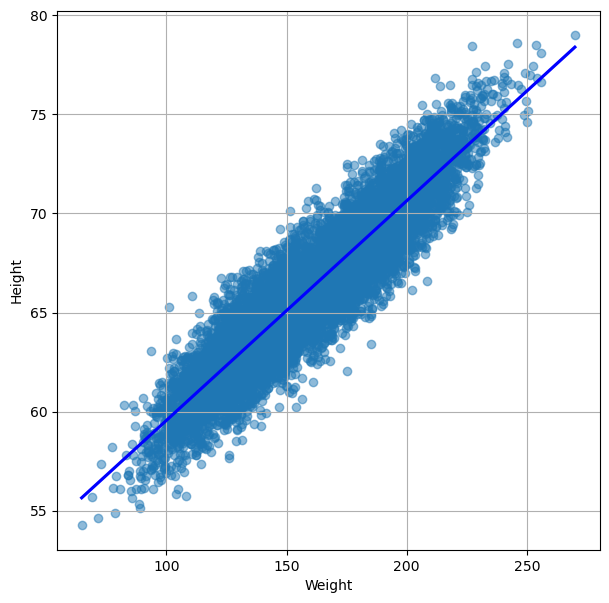

In [105]:
plt.figure(figsize=(7,7))
sns.regplot(x='Weight',
           y='Height',
           data=data,
           scatter_kws={'alpha':0.5}, 
           line_kws={'color':'blue'})
plt.xlabel('Weight')
plt.ylabel('Height')
plt.grid()
plt.show()

In [106]:
stats.pearsonr(data['Weight'],data['Height'])

PearsonRResult(statistic=0.9247562987409146, pvalue=0.0)

In [67]:
import statsmodels.api as sm

In [107]:
x=sm.add_constant(data['Weight'])
y=data['Height']

ols_model= sm.OLS(y,x).fit()

In [108]:
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Height   R-squared:                       0.855
Model:                            OLS   Adj. R-squared:                  0.855
Method:                 Least Squares   F-statistic:                 5.904e+04
Date:                Thu, 16 Jul 2026   Prob (F-statistic):               0.00
Time:                        03:14:23   Log-Likelihood:                -18002.
No. Observations:               10000   AIC:                         3.601e+04
Df Residuals:                    9998   BIC:                         3.602e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         48.4779      0.075    645.773      0.0

In [70]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

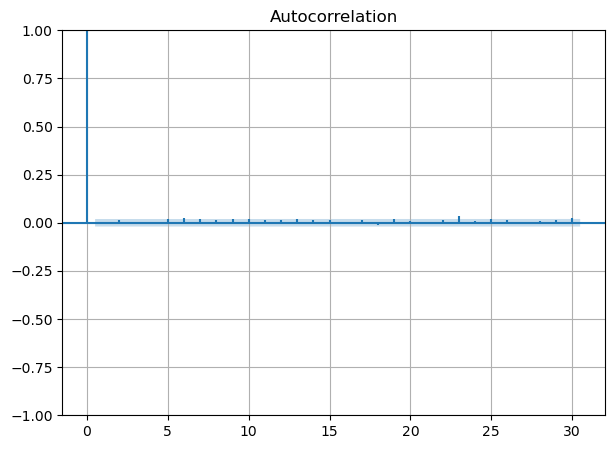

In [109]:
fig, ax= plt.subplots(figsize=(7,5))
plot_acf(ols_model.resid, marker='', ax=ax, lags=30);
plt.grid()

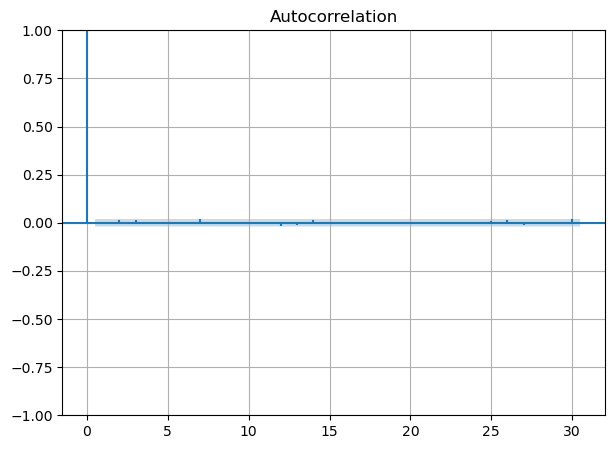

In [110]:
fig, ax= plt.subplots(figsize=(7,5))
plot_acf(ols_model.resid**2, marker='', ax=ax, lags=30);
plt.grid()

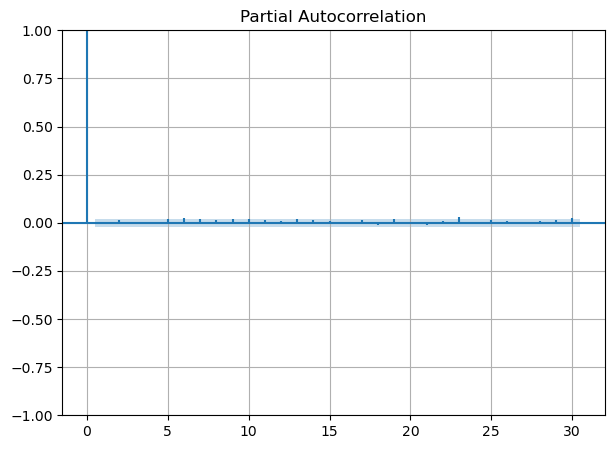

In [111]:
fig, ax= plt.subplots(figsize=(7,5))
plot_pacf(ols_model.resid, marker='', ax=ax, lags=30);
plt.grid()

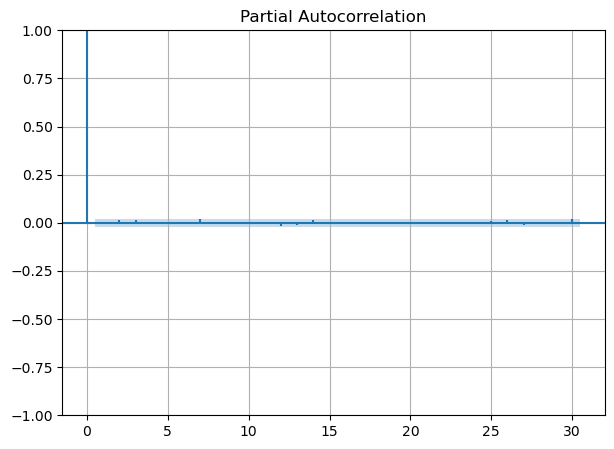

In [112]:
fig, ax= plt.subplots(figsize=(7,5))
plot_pacf(ols_model.resid**2, marker='', ax=ax, lags=30);
plt.grid()

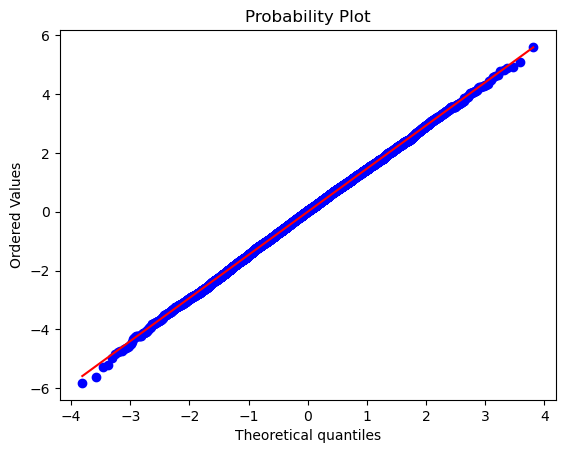

In [113]:
stats.probplot(ols_model.resid,dist='norm',plot=plt);

<Axes: ylabel='Frequency'>

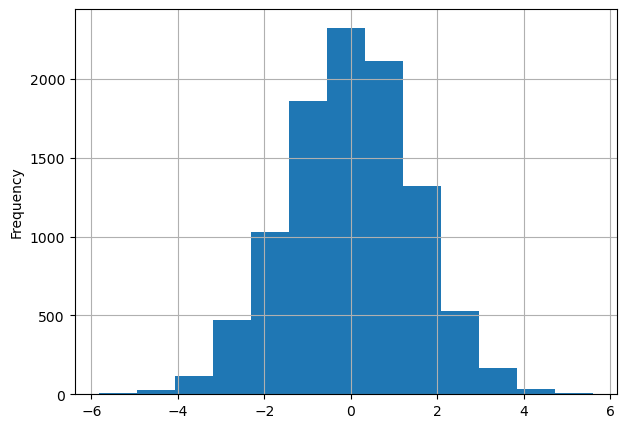

In [114]:
ols_model.resid.plot(kind='hist',grid=True,figsize=(7,5),bins=13)

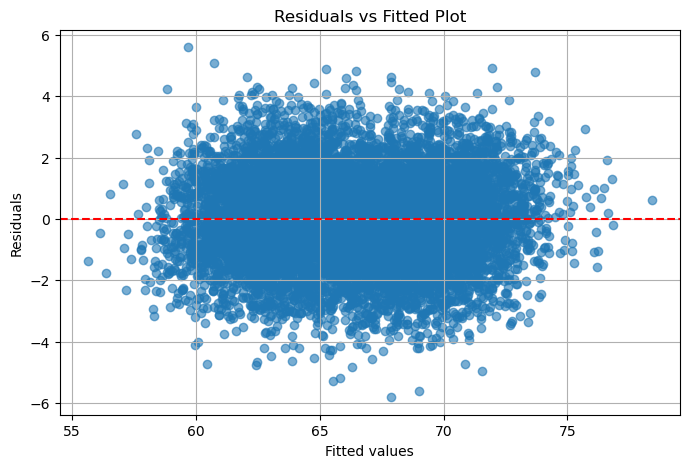

In [115]:
plt.figure(figsize=(8,5))
plt.scatter(ols_model.predict(x),ols_model.resid,alpha=0.6)
plt.axhline(y=0, color='red',linestyle='--')
plt.title('Residuals vs Fitted Plot')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.grid()
plt.show()

In [116]:
from statsmodels.stats.diagnostic import het_white

het_white(ols_model.resid, ols_model.model.exog)

(4.474525207494029,
 0.10675032271922981,
 2.237592641433595,
 0.10676854070622625)

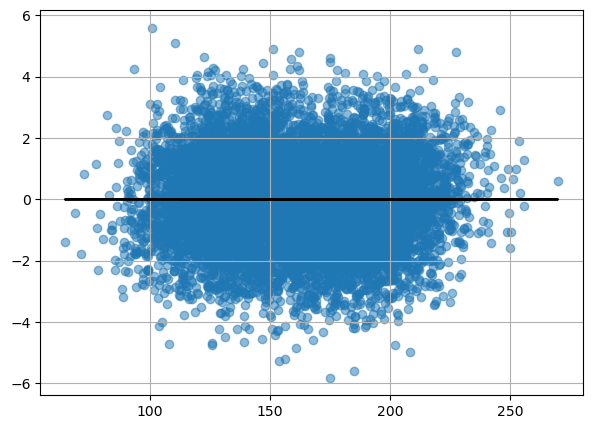

In [117]:
plt.figure(figsize=(7,5))
plt.scatter(x=data['Weight'], y=ols_model.resid,alpha=0.5)

m, c = np.polyfit(data['Weight'], ols_model.resid,1)
plt.plot(data['Weight'], data['Weight']*m + c, color='black')

plt.grid()
plt.show()

In [118]:
stats.pearsonr(data['Weight'], ols_model.resid)

PearsonRResult(statistic=-6.571132527000145e-15, pvalue=0.9999999999994628)